Define Results Tag
---

In [2]:
from datetime import datetime
RUNTAG = datetime.now().strftime("%Y_%d_%m")   


# <span style="color: Coral;"> Scenario config UI </span>

- Load the <span style="color: orange;"> _utils_ </span> module, which handles the backend functions to provide the <span style="color: blue;"> __scenario comnfig ui__ </span> 

In [3]:
import bcnexus.utils as utils
import re # For regex operations
scenarios_dd, storage_algo_dd, h_grouping_dd, n_clusters_dd, timeslices_label = utils.build_scenario_ui()

- Assign the <span style="color: orange;"> __values__</span>  from <span style="color: blue;"> __scenario UI dropdowns__</span> to <span style="color: orange;"> __arguments__</span> 

In [4]:
model_builder_args = dict(
    run_scenario=scenarios_dd.value ,
    storage_algorithm=storage_algo_dd.value,
    clustering_attributes=dict(
        hour_grouping=h_grouping_dd.value,
        n_clusters=n_clusters_dd.value
    )
)


# We use the Timeslices information to access run specific folders
timeslices_int = int(re.search(r'\d+', timeslices_label.value).group()) if re.search(r'\d+', timeslices_label.value) else None


# <span style="color: Coral;"> Model Runner Object </span>

* <span style="color: grey;">From `clews.runner` module, load the `RunModel` Object </span>  

In [5]:
from bcnexus.clews.runner import RunModel

* <span style="color: grey;"> Create an instance of the `RunModel` Object `bcnexusRun` with __model_builder_args__ </span>  

In [6]:
bcnexusRun = RunModel(**model_builder_args)

└> Initiated CLEWs Model Runner for 'Base_CNZ_noCCS' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
************************
Scenario: Base_CNZ_noCCS
************************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 4, 'n_clusters': 4}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE config from : models/model_Kotzur/otoole_config_Kotzur.yaml
 └> checking input CSVs...
 └> Copy

### 🚀 `run()` — Core Execution Workflow

* <span style="color: grey;"> Apply the `run()` method from  `bcnexusRun` instance </span> to run the complete workflow

About __Arguments__ of the `run()` method:

- `build=True` argument handles the workflow run to build SETs, Ratios, template params etc.
- `include_livestock` handles the livestock modelling workflow using `bcnexus/clews/livestock.py` module.
- `thread` depends on the hardware limitations of your machine. If you have 4 core CPU, use Thread __<=4__ )

* <span style="color: skyblue;"> Where do I get `threads` number ?</span>  
  - <span style="color: grey;"> Apply the `check_machine_cores()` function from  `utils` module. it returns the __number of cores available__ </span>  

In [7]:
n_physical_cores, n_logical_cores=utils.check_machine_cores()

ℹ️  Your machine has 24 physical cores and 32 logical cores.


| Model Characteristics                         | Recommended Threads | Reasoning                                                      |
| --------------------------------------------- | ------------------- | -------------------------------------------------------------- |
| Small LP/MILP (<50k vars)                     | 1–4                 | Over-parallelization adds overhead; single-thread often enough |
| Medium MILP (50k–500k vars)                   | 4–8                 | Good balance of parallel speed-up and stability                |
| Large/complex MILP (>500k vars, branch-heavy) | 8–16                | Parallel branch-and-bound scales moderately well               |
| Nonlinear / Quadratic / MIQP                  | 4–8                 | Solvers often rely on sequential matrix operations             |
| Highly degenerate or network-based LP         | 1–4                 | Parallel simplex often unstable; dual simplex preferred        |


* <span style="color: orange;">  Now run the Model ! </span>  

 <span style="color: coral;"> Important Notes:
  - While creating an instance of `RunModel` object (here named as `bcnexusRun`), it also creates an instance of `BuildModel` object (initiated and named as `ClewsBuilder` inside `RunModel` object ). You can access it via `bcnexusRun.ClewsBuilder`  , and access the methods inside `ClewsBuilder` object. 
  - The `ClewsBuilder` object can be found at </span> <span style="color: biege;"> bcnexus/clews/__builder.py__ module
  - when we set `build=True`. We use the `build()` method of `ClewsBuilder` object.
    - The `build()` method is useful to test/validate new structural changes to the model. This method handles the SETs creation, collection of LandCluster data, technology updates via clews_builder.yaml config. Refer to the script and the example workbook for more details on this object and methods.
    - `ClewsBuilder` has an explicit method `build_SETs_and_ratios` which is an adaptation of the former __clewsy__ tool. Developers can use this method and add their custom methods to incorporate new structural changes to the model.

<span style="color: coral;"> Data flow in folder:</span>
  - Everything happens inside : <span style="color: coral;"> data/clews_data</span>
  - The workflow __creates this directory__ : <span style="color: coral;">data/clews_data/<span style="color: magenta;">clews_build_data </span><br>
      <span style="color: grey;"> It has 3 sub-folders: 
      <span style="color: coral;">
      - input_csvs  <span style="color: grey;">: The workflow collects templates data first, then updates the files accordingly to reflect changes in clews_builder.yaml config. <span style="color: red;"> if `build`=False, then the workflow assumes all files are updated in this folder. Once you build the model structure, to adjust the temporal clustering attributes only, you can set `build=False`, to skip the steps to build this folder.
      - inputs_csv_8760<span style="color: grey;">: Creates BCNexus compatible profiling parameters in hourly resolution. Which are used to apply the clustering. <span style="color: red;"> if `build`=False, then the workflow assumes all files are updated in this folder.Once you build the model structure, to adjust the temporal clustering attributes only, you can set `build=False`, to skip the steps to build this folder.
      - Model_storage_algorithm<span style="color: grey;">: Final datafiles are stored inside this folder with storage case, and sub-folders with scenarios. 
  - Once you build the model structure, yt adjust the clustering attributes only, you can set `build=False`, to skip the steps to build this folder.


└>  Running CLEWs Builder to prepare SETs and Params for scenario: Base_CNZ_noCCS 
└> Building SETs and Ratios data...
 └> Collecting LandCluster data files...
⚠️  This model usages prepared LandCluster data. Ensure the data is prepared for the scenario being modelled.
ℹ️  Landcluster data source: models/LandClusterData
 └> Copying all CSV files : 'models/LandClusterData' >> 'data/clews_data/LandClusterData'
  └> Copied: clustering_results_prc_BC1.csv
  └> Copied: clustermap_table.csv
  └> Copied: clustering_results_BC1.csv
  └> Copied: clustering_results_evt_BC1.csv
  └> Copied: clustering_results_cwd_BC1.csv
*******************
Building CLEWs SETs
*******************
ℹ️  Saving to directory: data/clews_data/SETs
ℹ️  Model Structure: 'bcnexus/clews/model_structure.py'
  └> Checking Land Cluster Data files...
  └─> landcluser data source: data/clews_data/LandClusterData
  └─> ✔ All cluster files for land region 'BC1' found.
⚠️  Warning:  Import fuel CRU created for fuel that is not use


 └> Writing SETs to data/clews_data/SETs
  └> Writing YEAR to data/clews_data/SETs/YEAR.csv
  └> Writing EMISSION to data/clews_data/SETs/EMISSION.csv
  └> Writing REGION to data/clews_data/SETs/REGION.csv
  └> Writing TECHNOLOGY to data/clews_data/SETs/TECHNOLOGY.csv
  └> Writing FUEL to data/clews_data/SETs/FUEL.csv
  └> Writing MODE_OF_OPERATION to data/clews_data/SETs/MODE_OF_OPERATION.csv
  └> Writing Input Activity Ratios to data/clews_data/SETs/InputActivityRatio.csv
  └> Writing Output Activity Ratios to data/clews_data/SETs/OutputActivityRatio.csv
**************************
Limitations of build SETs:
**************************
⚠️  'INFLOW' fuel and the associated activity ratios are handled separately.
⚠️  Storage algorithm associated explicit sets are handled separately.
 └> Copying all CSV files : 'data/clews_data/SETs' >> 'data/clews_data/clews_build_data/input_csvs'
  └> Copied: MODE_OF_OPERATION.csv
  └> Copied: OutputActivityRatio.csv
  └> Copied: InputActivityRatio.csv

2026-07-13 22:01:20,311 - INFO - Set parameter Username


Set parameter LicenseID to value 2812656


2026-07-13 22:01:20,311 - INFO - Set parameter LicenseID to value 2812656


...

cost: 143443 rows, 167100 columns, 1473035 nonzeros


2026-07-13 22:01:20,843 - INFO - cost: 143443 rows, 167100 columns, 1473035 nonzeros


Set parameter LogToConsole to value 0


2026-07-13 22:01:20,844 - INFO - Set parameter LogToConsole to value 0
2026-07-13 22:01:20,844 - INFO - Set parameter Method to value 2
2026-07-13 22:01:20,844 - INFO - Set parameter Threads to value 32
2026-07-13 22:01:20,844 - INFO - Set parameter NumericFocus to value 2
2026-07-13 22:01:20,844 - INFO - Set parameter ScaleFlag to value 2
2026-07-13 22:01:20,844 - INFO - Set parameter BarHomogeneous to value 1
2026-07-13 22:01:20,844 - INFO - Set parameter LogFile to value "results/clews/Model_Kotzur_Base_CNZ_noCCS/24ts/gurobi.log"
2026-07-13 22:01:20,844 - INFO - Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 20.04.6 LTS")
2026-07-13 22:01:20,845 - INFO - 
2026-07-13 22:01:20,845 - INFO - CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
2026-07-13 22:01:20,845 - INFO - Thread count: 32 physical cores, 32 logical processors, using up to 32 threads
2026-07-13 22:01:20,845 - INFO - 
2026-07-13 22:01:20,845 - INFO - Non-default paramet

  └> --------------------------------------------------
  └─> Model run completed. Please check the log for detailed report.
 └> Optimization successful. An optimal solution is available.
└> Writing the Solution to : results/clews/Model_Kotzur_Base_CNZ_noCCS/24ts_2026_13_07/24ts_solution_gurobi.sol
└> Extracting the shadow price of Electricity (ELCB02) from Electricity Balance Constraint
└> Preparing the summary reports for constraints, from solved model
  └> Collecting constraints reports...
  └> Summary saved to results/clews/Model_Kotzur_Base_CNZ_noCCS/24ts_2026_13_07/constraints_summary.txt
 └> Duals extracted and saved to csv @ results/clews/Model_Kotzur_Base_CNZ_noCCS/24ts_2026_13_07/EBa11_EnergyBalanceEachTS5_duals.csv 
└> Extracting results from Solution : results/clews/Model_Kotzur_Base_CNZ_noCCS/24ts_2026_13_07/24ts_solution_gurobi.sol
 └> Initiating otoole interface to extract results; input csvs : data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs , confi

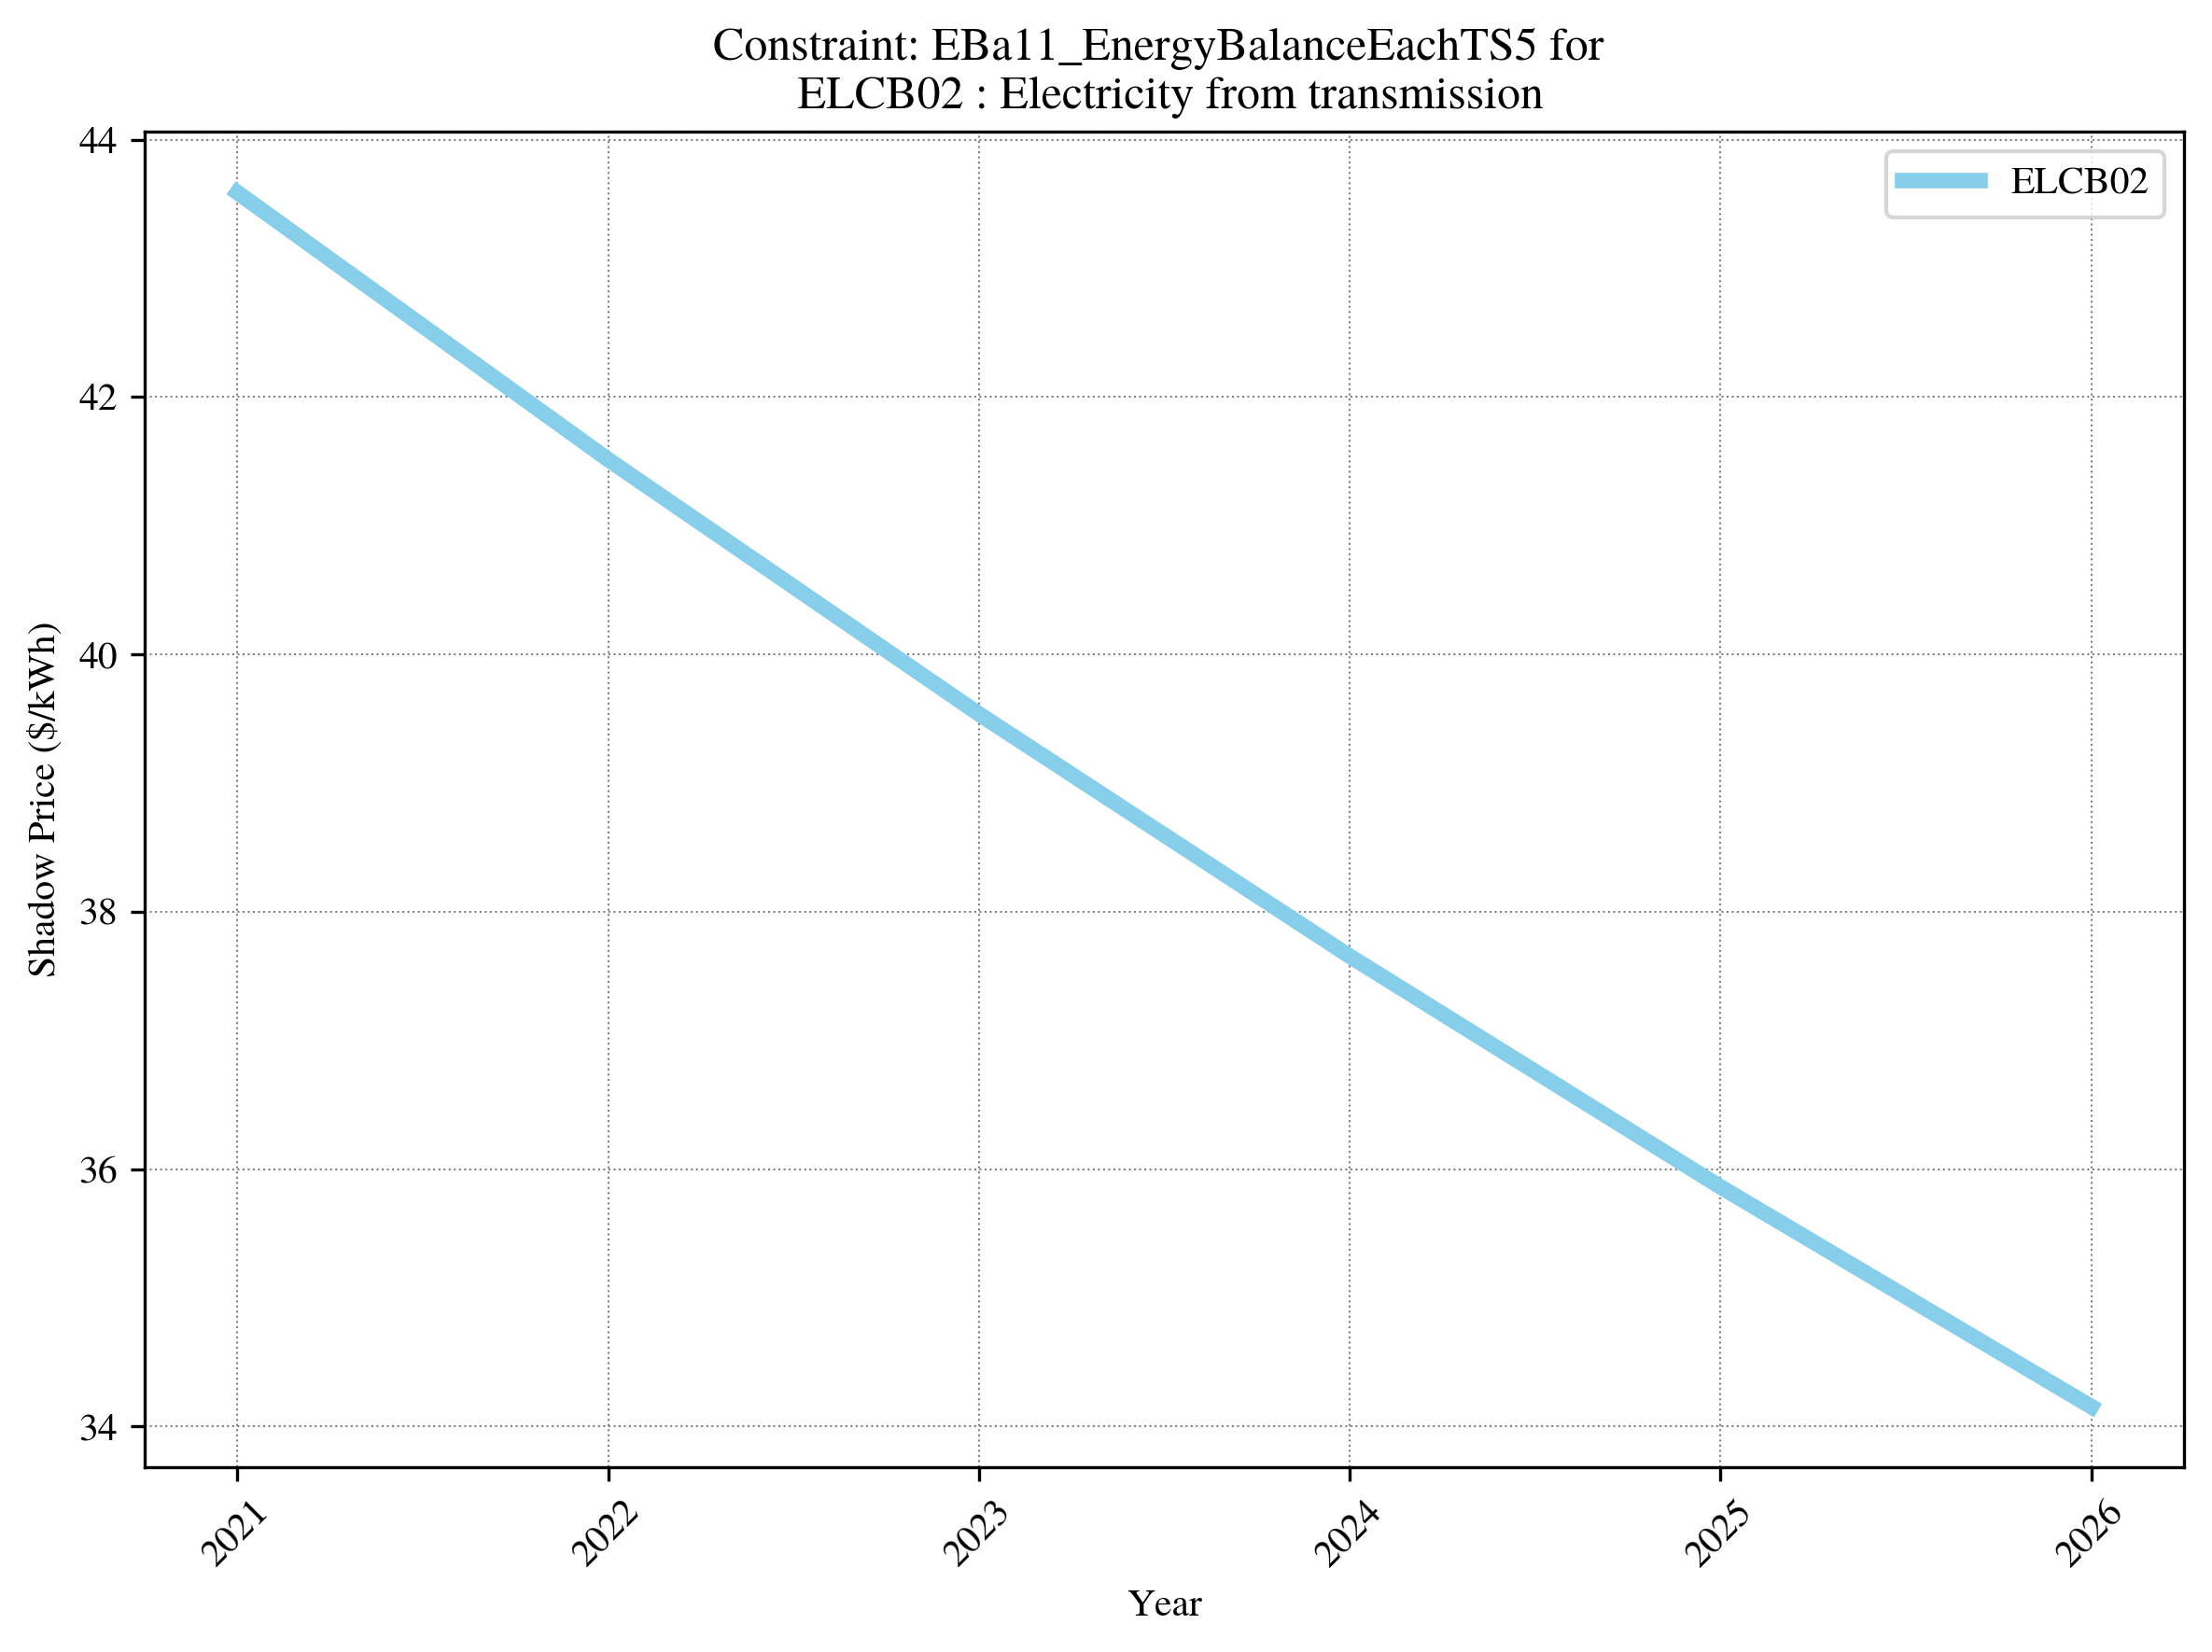

In [8]:
bcnexusRun.run(build=True,
             include_livestock=False,
             threads=32)

In [ ]:
# data_path,model_path=bcnexusRun.get_model_run_files()

In [ ]:
# bcnexusRun.write_LP_file(model_path,
#                        data_path,
#                        bcnexusRun.LP_file
#                        )

In [ ]:
# solved_m=bcnexusRun.solve_model_gurobi(bcnexusRun.LP_file,
#                             "log.txt")

In [ ]:
# bcnexusRun.solution_path = bcnexusRun.scenario_results_root/f'{bcnexusRun.timeslices}ts'/f'{bcnexusRun.timeslices}ts_solution_gurobi.sol' 

In [ ]:
# bcnexusRun.write_solution(solved_m,
#             bcnexusRun.solution_path)

In [ ]:
# shadow_price_ELCB02=bcnexusRun.get_shadow_price_ELCB02(solved_m,
#                 plot_save_to=bcnexusRun.scenario_results_root/f'{bcnexusRun.timeslices}ts'/f'shadowprice_ELC02_{bcnexusRun.timeslices}ts.png',
#                 show=False)

In [9]:
results_path=bcnexusRun.get_result_csvs(debug_mode=True)

 └> Initiating otoole interface to extract results; input csvs : data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs , config file: models/model_Kotzur/otoole_config_Kotzur.yaml


INFO:otoole.convert:Reading config from models/model_Kotzur/otoole_config_Kotzur.yaml
INFO:otoole.convert:Validating config from models/model_Kotzur/otoole_config_Kotzur.yaml
INFO:otoole.convert:Reading config from models/model_Kotzur/otoole_config_Kotzur.yaml
INFO:otoole.convert:Validating config from models/model_Kotzur/otoole_config_Kotzur.yaml
INFO:otoole.read_strategies:Looking for AccumulatedAnnualDemand
INFO:otoole.read_strategies:AccumulatedAnnualDemand is already in narrow form with headers ['REGION', 'FUEL', 'YEAR', 'VALUE']
INFO:root:Checking datatypes for AccumulatedAnnualDemand
INFO:otoole.read_strategies:Looking for AccumulatedNewCapacity
INFO:otoole.read_strategies:Looking for AnnualEmissionLimit
INFO:otoole.read_strategies:AnnualEmissionLimit is already in narrow form with headers ['REGION', 'EMISSION', 'YEAR', 'VALUE']
INFO:root:Checking datatypes for AnnualEmissionLimit
INFO:root:dtype of column VALUE does not match float for parameter AnnualEmissionLimit
INFO:otoole.

  └> Result extraction completed and saved to results/clews/Model_Kotzur_Base_CNZ_noCCS/24ts_csvs_gurobi_2026_13_07


In [10]:
from pathlib import Path
import bcnexus.plots as plotter
plotter.main(nexus_scenario=model_builder_args['run_scenario'],
             storage_algorithm=model_builder_args['storage_algorithm'],
             timeslices=bcnexusRun.timeslices,
             results_csvs=results_path,
             plots_save_to=Path(f'vis/{model_builder_args["run_scenario"]}/{bcnexusRun.timeslices}ts_{RUNTAG}'),)

Running CLEWs plotter:
  Scenario          : {nexus_scenario}
  Storage Algorithm : {storage_algorithm}
  Timeslices        : {timeslices}
└> Loaded 27 CSV files from results/clews/Model_Kotzur_Base_CNZ_noCCS/24ts_csvs_gurobi_2026_13_07
 └> Plotly Html file saved @ vis/Base_CNZ_noCCS/24ts_2026_13_07/Nexus_emission_total.html
 └> Plotly Html file saved @ vis/Base_CNZ_noCCS/24ts_2026_13_07/Nexus_emission_by_source.html
 └> Plotly Html file saved @ vis/Base_CNZ_noCCS/24ts_2026_13_07/Nexus_emission_by_sector.html
 └> Plotly Html file saved @ vis/Base_CNZ_noCCS/24ts_2026_13_07/Nexus_Landuse_for_clusters(.html
 └> Plotly Html file saved @ vis/Base_CNZ_noCCS/24ts_2026_13_07/Nexus_sectoral_consumption.html
 └> Plotly Html file saved @ vis/Base_CNZ_noCCS/24ts_2026_13_07/Nexus_Nexus_fuel_consumption.html
 └> Plotly Html file saved @ vis/Base_CNZ_noCCS/24ts_2026_13_07/Nexus_generation_from_fuels.html
 └> Plotly Html file saved @ vis/Base_CNZ_noCCS/24ts_2026_13_07/Nexus_capacity_investments.html
 

# <span style="color: Coral;"> Results </span>

### <span style="color: grey;"> Check Results @ `results\clews\<Model_<storage_algorithm>_<scenario>`</span>

- <span style="color: grey;"> We can also use the `datapackage` module's `GetDataPackage` object to load load the results as an object.
- <span style="color: grey;"> This results pack could be used for __post-analysis, result exchange to other models, visualizations, scenario dashes__ etc.

- <span style="color: grey;">  Get `result_pack` as an instance of `GetDataPackage` object

In [11]:
from bcnexus.clews.datapackage import GetDataPackage

nexus_results_root=f'results/clews/Model_{model_builder_args['storage_algorithm']}_{model_builder_args['run_scenario']}/{timeslices_int}ts_csvs_gurobi_{RUNTAG}'
result_pack=GetDataPackage(nexus_results_root)
result_pack.show

└> Loaded 27 CSV files from results/clews/Model_Kotzur_Base_CNZ_noCCS/24ts_csvs_gurobi_2026_13_07


['AccumulatedNewCapacity',
 'AnnualEmissions',
 'AnnualFixedOperatingCost',
 'AnnualTechnologyEmission',
 'AnnualTechnologyEmissionByMode',
 'AnnualVariableOperatingCost',
 'CapitalInvestment',
 'Demand',
 'DiscountedSalvageValue',
 'DiscountedTechnologyEmissionsPenalty',
 'NewCapacity',
 'ProductionByTechnology',
 'ProductionByTechnologyAnnual',
 'RateOfActivity',
 'RateOfProductionByTechnology',
 'RateOfProductionByTechnologyByMode',
 'RateOfUseByTechnology',
 'RateOfUseByTechnologyByMode',
 'SalvageValue',
 'StorageLevelChronoDayStart',
 'StorageLevelDayTypeFinish',
 'StorageLevelYearStart',
 'TotalAnnualTechnologyActivityByMode',
 'TotalCapacityAnnual',
 'TotalTechnologyAnnualActivity',
 'TotalTechnologyModelPeriodActivity',
 'UseByTechnology']

- <span style="color: grey;">  Apply `get_dataframe(<Result param name>)` method of the `result_pack` instance

In [12]:
#example
result_pack.get_dataframe('CapitalInvestment')

,REGION,TECHNOLOGY,YEAR,VALUE
0,REGION1,DEMINDDSL,2021,0.030565
1,REGION1,DEMINDDSL,2022,0.030368
2,REGION1,DEMINDDSL,2023,0.031218
3,REGION1,DEMINDDSL,2024,0.031900
4,REGION1,DEMINDDSL,2025,0.032556
...,...,...,...,...
331,REGION1,LNDWATBC1,2022,0.013649
332,REGION1,LNDWATBC1,2023,0.013677
333,REGION1,LNDWATBC1,2024,0.013649
334,REGION1,LNDWATBC1,2025,0.013656


# <span style="color: yellow;"> Plots </span>

!! <span style="color: biege;"> Still under active development to include more comprehensive plots <span style="color: yellow;"> EL_20251119

- <span style="color: biege;">  Load the `plotter` module. 
  - <span style="color: grey;"> plotter.`get_plots()` function returns a dictionary of plots. You can review the plots in this notebook from that dictionary. The function also save the plots as html to 'vis/bccm/< scenario > '

In [13]:
import bcnexus.plots as plotter

plotter_args=dict(
    nexus_scenario=model_builder_args['run_scenario'],
    storage_algorithm=model_builder_args['storage_algorithm'],
    timeslices=timeslices_int,
    results_csvs=nexus_results_root,
)
# plotter.main(**plotter_args)
nexus_plots=plotter.get_plots(**plotter_args)

└> Loaded 27 CSV files from results/clews/Model_Kotzur_Base_CNZ_noCCS/24ts_csvs_gurobi_2026_13_07
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_emission_total.html
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_emission_by_source.html
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_emission_by_sector.html
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_Landuse_for_clusters(.html
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_sectoral_consumption.html
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_Nexus_fuel_consumption.html
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_generation_from_fuels.html
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_capacity_investments.html
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_capacity_total.html
 └> Plotly Html file saved @ vis/bccm/Base_CNZ_noCCS/bc_nexus/Nexus_

In [23]:
nexus_plots['Energy'].keys()

dict_keys(['sectoral_consumption', 'Nexus_fuel_consumption', 'generation_from_fuels', 'capacity_investments', 'capacity_total', 'power_generation_timeslices', 'power_generation_annual', 'capital_investment_power'])

In [24]:
nexus_plots['Energy']['power_generation_timeslices']

# <span style="color: Coral;"> Playground for Solved Model </span>

* <span style="color: grey;">Load the Gurobi Model object as `m` from `clewsRun`'s attribute `solved_model` </span>  

In [15]:
m=bcnexusRun.solved_model

In [16]:
m.printStats()          # Print basic stats: number of vars, constraints, etc.

2026-07-13 22:02:57,075 - INFO - Statistics for model 'cost':
2026-07-13 22:02:57,076 - INFO -   Problem type                : LP
2026-07-13 22:02:57,076 - INFO -   Linear constraint matrix    : 143443 rows, 167100 columns, 1473035 nonzeros
2026-07-13 22:02:57,077 - INFO -   Variable types              : 167100 continuous, 0 integer (0 binary)
2026-07-13 22:02:57,077 - INFO -   Matrix range                : [9e-09, 1e+06]
2026-07-13 22:02:57,077 - INFO -   Objective range             : [2e-04, 2e+08]
2026-07-13 22:02:57,077 - INFO -   Bounds range                : [0e+00, 0e+00]
2026-07-13 22:02:57,077 - INFO -   RHS range                   : [2e-05, 1e+08]


In [17]:
m.getAttr('Obj')     # Get objective coefficients

[17700000.0,
 176999823.0,
 16857142.8571428,
 168571260.0,
 16054421.7687075,
 160544057.142857,
 15289925.4940071,
 152899102.040817,
 14561833.8038162,
 145618192.419825,
 13868413.1464918,
 138683992.780785,
 -177.0,
 -177.0,
 -177.0,
 -177.0,
 -177.0,
 -177.0,
 -177.0,
 -177.0,
 -177.0,
 -177.0,
 -177.0,
 -177.0,
 0.01,
 0.00952380952380952,
 0.0090702947845805,
 0.00863837598531476,
 0.00822702474791882,
 0.00783526166468459,
 0.01,
 0.00952380952380952,
 0.0090702947845805,
 0.00863837598531476,
 0.00822702474791882,
 0.00783526166468459,
 0.01,
 0.00952380952380952,
 0.0090702947845805,
 0.00863837598531476,
 0.00822702474791882,
 0.00783526166468459,
 0.01,
 0.00952380952380952,
 0.0090702947845805,
 0.00863837598531476,
 0.00822702474791882,
 0.00783526166468459,
 0.01,
 0.00952380952380952,
 0.0090702947845805,
 0.00863837598531476,
 0.00822702474791882,
 0.00783526166468459,
 0.01,
 0.00952380952380952,
 0.0090702947845805,
 0.00863837598531476,
 0.00822702474791882,
 0.007

In [18]:
m.getConstrs()          # List of all constraint objects

[<gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2021)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2022)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2023)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2024)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2025)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2026)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDBIO,2021)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDBIO,2022)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDBIO,2023)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDBIO,2024)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDBIO,2025)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDBIO,2026)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDNGS,2021)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDNGS,2022)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDNGS,2023)>,
 <gurobi.Constr CAa1_TotalNewCapacity(RE

#### <span style="color: orange;">  Define or Modify the Model </span> 

In [19]:
# x = m.addVar(lb=0, ub=10, obj=3, name='x')
# y = m.addVar(lb=0, ub=GRB.INFINITY, obj=1, name='y')
# m.addConstr(2*x + 3*y >= 10, name='demand_constraint')
# m.setObjective(3*x + 1*y, GRB.MINIMIZE)


* <span style="color: grey;">Load the `plotter` module and use the `main()` function </span>